In [6]:
!pip install qiskit matplotlib numpy qiskit[visualization]
# installing the packages qiskit (for simulating circuits), matplotlib (for graphing), numpy (for efficient number calculations), and qiskit visualizations (for drawing circuits)

In [7]:
from qiskit import QuantumCircuit
# imports the class QuantumCircuit to create a circuit object
from qiskit.primitives import StatevectorSampler
# the statevectorsampler object is a tool that can simulate the quantum state
import numpy as np
#importing numnpy as np tells the notebook to recognize np as the numpy package and helps simplify code expression

In [13]:
qc = QuantumCircuit(2)
#This creates a quantum circuit with 2 qubits.

qc.h(0)
#Applies a hadamard gate to the first qubit, putting it in an even superposition of "on" and "off."

qc.x(1)
#Applies a X gate to the second qubit, flipping to be in the "off" state.

qc.cx(0,1)
#Applies a controlled X gate to the first and second qubits, with the first qubit as the control qubit and the second qubit as the target qubit.
#This creates the Psi+ bell state, where the qubits are anticorrelated.

qc.measure_all()
#measures the state of all qubits

In [51]:
sampler = StatevectorSampler()
#initializes the sampler so we can actually simulate the quantum circuit qc

result = sampler.run([qc]).result()
# simulates the circuit 1024 (the default number of shots) times, stores it in 'result' assuming no noise

print(result[0].data.meas.get_counts())
#prints the output state and counts for each state after 1024 measurements


singleresult = sampler.run([qc], shots = 1).result()
#simulates the circuit once and stores the value in singleresult

print(singleresult[0].data.meas.get_counts())
#prints output state after measturing the qubit one time

{'01': 506, '10': 518}
{'10': 1}


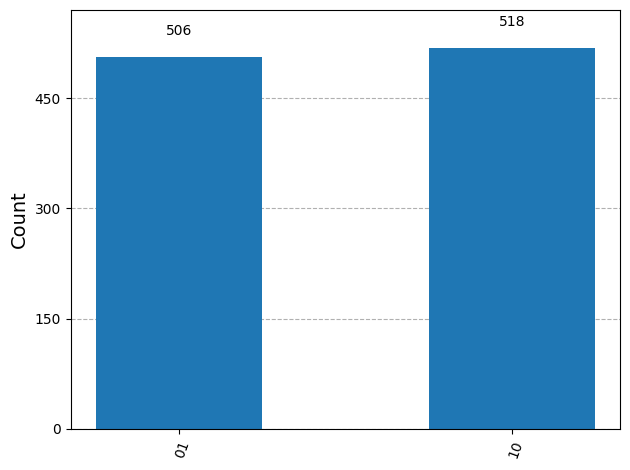

In [52]:
# Now we're going to plot our counts from the first simulation in a histogram to visualize the distribution of outcomes.
from qiskit.visualization import plot_histogram
#This imports the function to actually plot the data from our simulation as a histogram

counts = result[0].data.meas.get_counts()
#This is the data that we were printing in the previous cell, accept we are going to plot it in a grpah instead of printing it as text

plot_histogram(counts)
# The plot_histogram() function will take the information in counts and graph it